# Playing Time / Rotation Model — Role Fit Opportunity Scorer

Interactive companion to `src/portalpoint/modeling/playing_time.py` / `scripts/run_playing_time.py`,
matching the script/notebook-in-sync pattern used by `scheme_fit_scorer.ipynb` and
`gap_matching.ipynb` (CLAUDE.md TODO #4). All fit/score/write logic lives in the `playing_time`
module — this notebook is for model-family benchmarking, calibration review, and the hand-picked
constant sensitivity checks the script itself doesn't expose (role_fit weights, minutes/usage role
thresholds, the freshman-prior-shrinkage on/off comparison).

Full design/contract: `docs/models/playing_time_rotation_model_plan.md`. Production rerun:
`scripts/run_playing_time.py` (handles MLflow tracking + the promotion gate — this notebook does
not write to MLflow).

**Model version:** `playing-time-rotation-v2`

In [1]:
# Cell 0 — Imports + Config
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from portalpoint.modeling import playing_time as pt
from portalpoint.modeling.io import get_sync_engine

MODEL_VERSION = pt.MODEL_VERSION
TRAIN_SEASONS = list(range(2021, 2027))
SOURCE_SEASON = 2026
ROSTER_SEASON = 2026
FIT_CONTEXT_SEASON = 2026
TEAM_CONTEXT_SEASON = 2026
PROJECTION_SEASON = 2027
MODEL_FAMILIES_TO_BENCHMARK = ["hist_gradient_boosting", "extra_trees"]

engine = get_sync_engine()
print(f"Model version: {MODEL_VERSION}")
print(f"Train seasons: {TRAIN_SEASONS}")
print(f"Target/projection season: {PROJECTION_SEASON} (source={SOURCE_SEASON})")

Model version: playing-time-rotation-v2
Train seasons: [2021, 2022, 2023, 2024, 2025, 2026]
Target/projection season: 2027 (source=2026)


## 1. Roster Coverage Audit

Confirms a roster snapshot and a `player_team_fit_scores` row set exist for the seasons this
notebook will train/score against, before sinking time into a run that has nothing to join to.

In [2]:
# Cell 1 — Roster coverage audit
from sqlalchemy import text

with engine.connect() as conn:
    fit_seasons = [
        int(r[0])
        for r in conn.execute(
            text("SELECT DISTINCT season FROM player_team_fit_scores ORDER BY season")
        ).fetchall()
    ]
    roster_seasons = [
        int(r[0])
        for r in conn.execute(
            text("SELECT DISTINCT season FROM roster_baseline_members ORDER BY season")
        ).fetchall()
    ]
    fallback_versions = conn.execute(
        text(
            "SELECT model_version, season, count(*) FROM player_projections "
            "WHERE school_id IS NULL AND projection_mode = 'neutral' "
            "GROUP BY 1, 2 ORDER BY 2, 1"
        )
    ).fetchall()

print(f"player_team_fit_scores seasons: {fit_seasons}")
print(f"roster_baseline_members seasons: {roster_seasons}")
print("\nplayer_projections (neutral) coverage by model_version/season:")
for version, season, n in fallback_versions:
    flag = " <- forecast model" if version == pt.PLAYER_PROJECTION_MODEL_VERSION else ""
    print(f"  {version:35s} season={season} n={n:,}{flag}")
print(
    "\nIf the forecast model_version above has near-zero rows for these seasons, "
    "null_leaking_neutral_projection_features() (Cell 2) will neutralize most/all rows' "
    "value_per_100/skill_percentiles/uncertainty features rather than risk leaking same-season "
    "production into the minutes/usage labels — see neutral_projection_fallback_rate below."
)

player_team_fit_scores seasons: [2021, 2022, 2023, 2024, 2025, 2026]
roster_baseline_members seasons: [2021, 2022, 2023, 2024, 2025, 2026]

player_projections (neutral) coverage by model_version/season:
  player-projection-phase2a-v1        season=2020 n=3,253
  player-projection-phase2a-v1        season=2021 n=4,674
  player-projection-shrinkage-v1      season=2021 n=4,266
  player-projection-phase2a-v1        season=2022 n=5,156
  player-projection-shrinkage-v1      season=2022 n=4,538
  player-projection-phase2a-v1        season=2023 n=5,134
  player-projection-shrinkage-v1      season=2023 n=4,556
  player-projection-phase2a-v1        season=2024 n=5,205
  player-projection-shrinkage-v1      season=2024 n=4,565
  player-projection-phase2a-v1        season=2025 n=5,255
  player-projection-shrinkage-v1      season=2025 n=4,571
  player-projection-phase2a-v1        season=2026 n=4,863
  player-projection-shrinkage-v1      season=2026 n=4,551
  player-proj-phase2a-fcast-v1        seaso

## 2. Build Training Examples

`pt.build_training_examples` already applies `null_leaking_neutral_projection_features` internally.
`neutral_projection_fallback_rate` here is purely diagnostic, to see how much of the training set
is currently running on roster/fit/team context alone (no real `value_per_100` signal) vs. the real
forecast projection.

In [3]:
# Cell 2 — Build training examples
train_df = pt.build_training_examples(engine, TRAIN_SEASONS)
fallback_rate = pt.neutral_projection_fallback_rate(train_df)

print(f"Training rows: {len(train_df):,} across seasons {TRAIN_SEASONS}")
print(f"Same-season neutral-projection fallback rate: {fallback_rate:.4f}")
train_df[["season", "actual_minutes_share", "actual_usage_rate"]].describe()

Training rows: 27,046 across seasons [2021, 2022, 2023, 2024, 2025, 2026]
Same-season neutral-projection fallback rate: 1.0000


,season,actual_minutes_share,actual_usage_rate
count,27046.000000,27046.000000,27046.000000
mean,2023.528026,0.397910,18.347737
std,1.696628,0.267483,5.430412
min,2021.000000,0.002000,0.000000
25%,2022.000000,0.147000,14.700000
50%,2024.000000,0.396000,18.100000
75%,2025.000000,0.633000,21.800000
max,2026.000000,0.988000,48.200000


## 3. Build Candidate / Destination Examples (Inference Pairs)

Same `build_inference_pairs` call the production script makes per school-chunk — sampled small
here just to inspect the candidate-pool shape (this is the "every eligible player scored against
one destination" frame `compress_usage_to_roster_budget` and the freshman-prior shrinkage both
operate on).

In [4]:
# Cell 3 — Sample candidate/destination examples for one school
SAMPLE_SCHOOL_IDS = [1]

sample_pairs = pt.build_inference_pairs(
    engine,
    PROJECTION_SEASON,
    SAMPLE_SCHOOL_IDS,
    source_season=SOURCE_SEASON,
    roster_season=ROSTER_SEASON,
    fit_context_season=FIT_CONTEXT_SEASON,
    team_context_season=TEAM_CONTEXT_SEASON,
)
print(f"Candidate rows for school_id={SAMPLE_SCHOOL_IDS}: {len(sample_pairs):,}")
sample_pairs[["player_id", "school_id", "position", "prior_minutes", "is_portal_candidate"]].head(10)

Candidate rows for school_id=[1]: 4,551


,player_id,school_id,position,prior_minutes,is_portal_candidate
0,3380822651791868070,1,SG,22.60,False
1,234536378925866940,1,C,26.88,False
2,4950050758068501372,1,PG,27.08,False
3,7889624279021967427,1,PF,16.56,False
4,6431921145346652168,1,SG,32.40,False
5,8619035370291920195,1,SF,29.12,False
6,2085272699301658196,1,SG,30.68,False
7,4213026342866155483,1,SF,24.28,False
8,2008403521346813660,1,SG,17.32,False
9,2211570573433262989,1,PG,20.52,False


## 4. Train Minutes / Usage Models + Rolling-Origin Benchmark

Mirrors `scripts/run_playing_time.py`'s `resolve_holdout_seasons`/`rolling_origin_validation`
(3-fold rolling-origin, matching Player Projection's house validation convention) but inline here
so model families can be compared side by side with a plot before picking one for production.

,minutes_rmse,minutes_mae,usage_rmse,usage_mae
model_family,,,,
extra_trees,5.6278,4.2297,4.7752,3.5804
hist_gradient_boosting,5.5329,4.1456,4.8548,3.6688


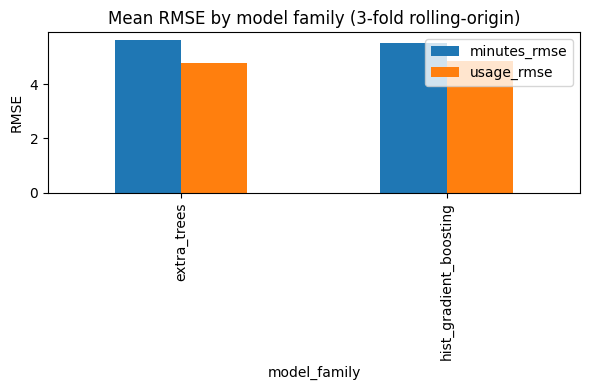

In [5]:
# Cell 4 — Rolling-origin holdout benchmark across model families
def resolve_holdout_seasons(seasons, n_folds=3):
    ordered = sorted(set(seasons))
    holdouts = []
    for season in reversed(ordered):
        if len([s for s in ordered if s < season]) < 2:
            continue
        holdouts.append(season)
        if len(holdouts) >= n_folds:
            break
    return sorted(holdouts)


def score_holdout(train_df, holdout_season, model_family):
    fit_df = train_df[train_df["season"] < holdout_season].reset_index(drop=True)
    val_df = train_df[train_df["season"] == holdout_season].reset_index(drop=True)
    if fit_df.empty or val_df.empty:
        return None
    models = pt.fit_minutes_usage_models(fit_df, model_family=model_family)
    scored = pt.predict_minutes_usage(models, val_df)
    metrics = pt.validate_predictions(scored)
    metrics["holdout_season"] = holdout_season
    metrics["model_family"] = model_family
    return metrics


holdout_seasons = resolve_holdout_seasons(TRAIN_SEASONS)
benchmark_rows = []
for model_family in MODEL_FAMILIES_TO_BENCHMARK:
    for holdout_season in holdout_seasons:
        result = score_holdout(train_df, holdout_season, model_family)
        if result:
            benchmark_rows.append(result)

benchmark_df = pd.DataFrame(benchmark_rows)
summary = benchmark_df.groupby("model_family")[["minutes_rmse", "minutes_mae", "usage_rmse", "usage_mae"]].mean()
display(summary.round(4))

summary[["minutes_rmse", "usage_rmse"]].plot(kind="bar", figsize=(6, 4), title="Mean RMSE by model family (3-fold rolling-origin)")
plt.ylabel("RMSE")
plt.tight_layout()
plt.show()

## 5. Freshman Prior Shrinkage — On/Off Comparison

`apply_freshman_shrinkage` defaults to `False` in `fit_minutes_usage_models` — a real rolling-origin
run found it *increases* `minutes_mae`/`minutes_rmse` (~+11%) rather than helping, the same
theoretically-motivated-but-measured-worse situation as Player Projection's Gap B context
adjustment. This cell reproduces that comparison directly so the finding stays visible/re-checkable
here rather than only living in a commit message.

In [6]:
# Cell 5 — Freshman-prior shrinkage on vs. off, same holdout fold
BEST_FAMILY = summary["minutes_rmse"].idxmin()
holdout_for_comparison = holdout_seasons[-1]
fit_df = train_df[train_df["season"] < holdout_for_comparison].reset_index(drop=True)
val_df = train_df[train_df["season"] == holdout_for_comparison].reset_index(drop=True)

rows = []
for shrinkage_on in (False, True):
    models = pt.fit_minutes_usage_models(
        fit_df, model_family=BEST_FAMILY, apply_freshman_shrinkage=shrinkage_on
    )
    scored = pt.predict_minutes_usage(models, val_df)
    metrics = pt.validate_predictions(scored)
    metrics["apply_freshman_shrinkage"] = shrinkage_on
    rows.append(metrics)

pd.DataFrame(rows)[
    ["apply_freshman_shrinkage", "minutes_mae", "minutes_rmse", "minutes_bias", "usage_mae", "usage_rmse"]
]

,apply_freshman_shrinkage,minutes_mae,minutes_rmse,minutes_bias,usage_mae,usage_rmse
0,False,4.220598,5.621710,0.228106,3.712634,4.892662
1,True,4.676541,5.982924,0.341195,3.710846,4.882650


## 6. Usage Compression Sanity Check

`compress_usage_to_roster_budget` pulls each candidate's predicted usage toward the real
per-position `open_usage_position` figure (not a sum across the whole candidate pool — see the
function's docstring for why the naive group-sum version broke down at real inference scale).
Confirms the distribution shift is a modest pull, not a crush.

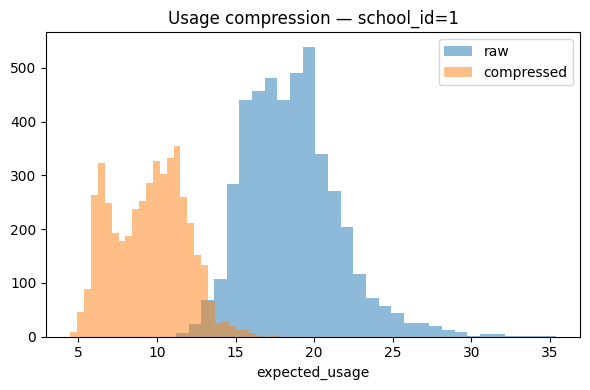

Rows with usage pulled down: 100.0%


In [7]:
# Cell 6 — Usage compression before/after, real candidate pool
production_models = pt.fit_minutes_usage_models(train_df, model_family=BEST_FAMILY)
scored_sample = pt.predict_minutes_usage(production_models, sample_pairs)
compressed_sample = pt.compress_usage_to_roster_budget(scored_sample)

fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(compressed_sample["expected_usage_raw"], bins=30, alpha=0.5, label="raw")
ax.hist(compressed_sample["expected_usage"], bins=30, alpha=0.5, label="compressed")
ax.set_xlabel("expected_usage")
ax.legend()
plt.title(f"Usage compression — school_id={SAMPLE_SCHOOL_IDS[0]}")
plt.tight_layout()
plt.show()

pct_affected = (compressed_sample["expected_usage"] < compressed_sample["expected_usage_raw"]).mean()
print(f"Rows with usage pulled down: {pct_affected:.1%}")

## 7. Usage Role + Role Fit Review

`derive_usage_role`'s role scores and `compute_role_fit_score`'s weights
(0.48 minutes / 0.22 role-path / 0.18 usage / 0.12 opportunity, minus uncertainty/crowding
penalties) are hand-picked constants with no tuning trail in the original PR. This cell at least
makes their effect visible on real data so a future tuning pass has a starting distribution to
compare against.

usage_role
depth                   2398
rim_runner_rebounder    1006
primary_creator          586
spacing_specialist       560
connector                  1
Name: count, dtype: int64


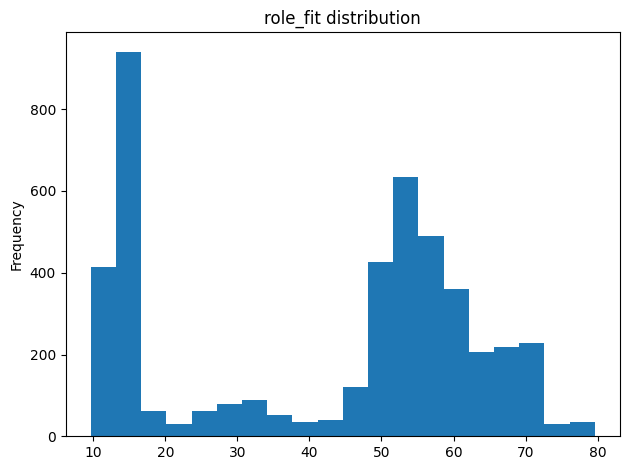

,count,mean,std
usage_role,,,
connector,1.0,63.110000,NaN
depth,2398.0,30.208795,20.057971
primary_creator,586.0,63.585597,7.685766
rim_runner_rebounder,1006.0,52.982396,12.312476
spacing_specialist,560.0,51.198625,12.190389


In [8]:
# Cell 7 — Usage role distribution + role_fit sanity check
roles = compressed_sample.apply(pt.derive_usage_role, axis=1)
compressed_sample["usage_role"] = [r[0] for r in roles]
compressed_sample["usage_role_confidence"] = [r[1] for r in roles]
compressed_sample["role_fit"] = compressed_sample.apply(pt.compute_role_fit_score, axis=1)

print(compressed_sample["usage_role"].value_counts())
compressed_sample["role_fit"].plot(kind="hist", bins=20, title="role_fit distribution")
plt.tight_layout()
plt.show()

compressed_sample.groupby("usage_role")["role_fit"].describe()[["count", "mean", "std"]]

## 8. Validation Summary

Full `validate_predictions` metric set (calibration, tail precision/recall, Brier scores) for the
chosen production family on the most recent holdout fold — the same metrics
`scripts/run_playing_time.py` logs to MLflow.

In [9]:
# Cell 8 — Full validation metric set, most recent holdout fold
final_scored = pt.predict_minutes_usage(
    pt.fit_minutes_usage_models(fit_df, model_family=BEST_FAMILY), val_df
)
pd.Series(pt.validate_predictions(final_scored)).sort_index()

actual_minutes_mean                 16.014336
actual_usage_mean                   18.284807
avg_interval_width                  16.759461
heavy_minutes_brier_32mpg            0.048396
high_usage_brier_26                  0.067454
interval_coverage                    0.885884
interval_coverage_error_80pct        0.085884
interval_width_to_mae_ratio          3.970874
median_interval_width               15.480000
minutes_24_plus_actual_rate          0.284301
minutes_24_plus_precision            0.624000
minutes_24_plus_predicted_rate       0.247361
minutes_24_plus_recall               0.542923
minutes_32_plus_actual_rate          0.061346
minutes_32_plus_precision            0.458333
minutes_32_plus_predicted_rate       0.015831
minutes_32_plus_recall               0.118280
minutes_bias                         0.228106
minutes_distribution_tvd             0.167766
minutes_mae                          4.220598
minutes_rmse                         5.621710
n_validation_rows                 

## 9. DB Write (gated — off by default)

Production writes belong in `scripts/run_playing_time.py` (it owns MLflow tracking and the
promotion gate). This cell exists for one-off manual spot-checks only — flip `SHOULD_WRITE` and
narrow `SAMPLE_SCHOOL_IDS` above before ever running it for real.

In [10]:
# Cell 9 — Gated DB write (manual spot-check only)
SHOULD_WRITE = False

if SHOULD_WRITE:
    scored_for_write = pt.compress_usage_to_roster_budget(
        pt.predict_minutes_usage(production_models, sample_pairs)
    )
    roles = scored_for_write.apply(pt.derive_usage_role, axis=1)
    scored_for_write["usage_role"] = [r[0] for r in roles]
    scored_for_write["usage_role_confidence"] = [r[1] for r in roles]
    scored_for_write["role_fit"] = scored_for_write.apply(pt.compute_role_fit_score, axis=1)

    projection_records, sync_records = pt.build_playing_time_records(scored_for_write)
    written = pt.upsert_playing_time_projections(engine, projection_records)
    synced = pt.sync_role_fit_scores(engine, sync_records)
    print(f"Wrote {written:,} playing_time_projections rows, synced {synced:,} fit-score rows")
else:
    print("SHOULD_WRITE is False — no DB write performed. Use scripts/run_playing_time.py for production runs.")

SHOULD_WRITE is False — no DB write performed. Use scripts/run_playing_time.py for production runs.
